In [181]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer

In [183]:
df=pd.read_csv("cleaned_data.csv")

In [184]:
df.head()

,emp_length,grade,member_id,term,annual_income,dti,installment,int_rate,loan_amount,total_acc,...,purpose_major purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small business,purpose_vacation,purpose_wedding,verification_status_Source Verified,verification_status_Verified
0,4.0,3.0,1.251026e+06,36.0,82438.124601,0.072151,62.006774,0.161206,9586.945180,1.953600,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,3.0,2.0,2.947135e+05,36.0,52347.892639,0.140367,373.547998,0.117188,2213.200815,22.458280,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,7.0,6.0,1.027941e+06,60.0,254889.785659,0.148349,1057.386266,0.171302,16700.391717,2.814647,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,10.0,2.0,1.087496e+06,60.0,96793.334996,0.143274,510.555677,0.091857,4109.600739,15.353574,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5.0,3.0,1.080071e+06,36.0,134563.215178,0.068504,557.719321,0.157557,4864.419363,21.583704,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [187]:
df.shape

(56815, 99)

In [189]:
columns_to_check=['annual_income', 'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc', 'total_payment']

#### Removing outliers

In [191]:
from scipy.stats import zscore
z_scores = df[columns_to_check].apply(zscore)
threshold = 3
df1 = df[(z_scores.abs() < threshold).all(axis=1)]

In [193]:
df1.head()

,emp_length,grade,member_id,term,annual_income,dti,installment,int_rate,loan_amount,total_acc,...,purpose_major purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small business,purpose_vacation,purpose_wedding,verification_status_Source Verified,verification_status_Verified
0,4.0,3.0,1.251026e+06,36.0,82438.124601,0.072151,62.006774,0.161206,9586.945180,1.953600,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,3.0,2.0,2.947135e+05,36.0,52347.892639,0.140367,373.547998,0.117188,2213.200815,22.458280,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,10.0,2.0,1.087496e+06,60.0,96793.334996,0.143274,510.555677,0.091857,4109.600739,15.353574,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5.0,3.0,1.080071e+06,36.0,134563.215178,0.068504,557.719321,0.157557,4864.419363,21.583704,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,10.0,1.0,6.158979e+05,60.0,45075.969477,0.165688,54.284249,0.151245,10092.561386,9.717055,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [195]:
df1.shape

(54941, 99)

C:\Users\subas\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\subas\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='loan_amount', ylabel='Count'>

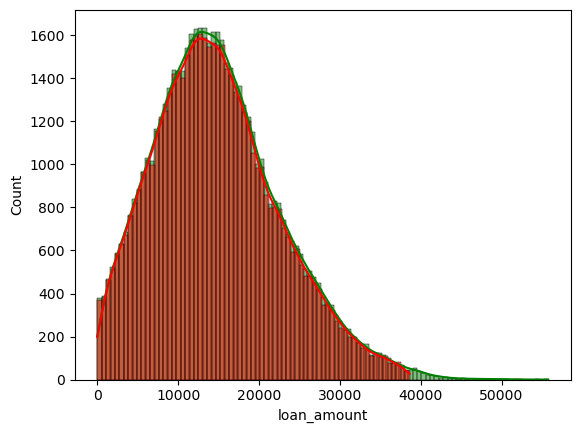

In [221]:
sns.histplot(df.loan_amount,kde=True,color="green")
sns.histplot(df1.loan_amount,kde=True,color="red")

## Model Training

In [205]:
X=df1.drop(columns=["grade"])
y=df1["grade"]

In [207]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [209]:
minmax_scaler=MinMaxScaler()
X_train=minmax_scaler.fit_transform(X_train)
X_test=minmax_scaler.transform(X_test)

In [211]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

In [213]:
models={
    "Random Forest":RandomForestClassifier(),
    # "Gradient Boosting":GradientBoostingClassifier()
}

In [215]:
for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    print(f"{name} accuracy: {accuracy_score(y_test,y_pred)}")

Random Forest accuracy: 0.5894985894985895
